In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical libraries
from scipy import stats

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
# Load cleaned dataset

df = pd.read_csv("../data/processed/movies_cleaned.csv")


df.head()

,title,year,budget,revenue,vote_average,vote_count,popularity,female_ratio,female_director,bechdelRating,imdbAverageRating,numVotes,runtimeMinutes,genre1,genre2,genre3
0,Avatar,2009.0,237000000,2787965087,7.2,11800,150.437577,0.144578,0,3.0,7.9,1389834.0,162.0,Action,Adventure,Fantasy
1,Pirates of the Caribbean: At World's End,2007.0,300000000,961000000,6.9,4500,139.082615,0.147059,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Spectre,2015.0,245000000,880674609,6.3,4466,107.376788,0.156627,0,1.0,6.8,467291.0,148.0,Action,Adventure,Thriller
3,The Dark Knight Rises,2012.0,250000000,1084939099,7.6,9106,112.312950,0.069620,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,John Carter,2012.0,260000000,284139100,6.1,2124,43.926995,0.222222,0,3.0,6.6,286786.0,132.0,Action,Adventure,Sci-Fi


In [3]:
# Basic dataset information

print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns)

Dataset shape: (3231, 16)

Columns:
 Index(['title', 'year', 'budget', 'revenue', 'vote_average', 'vote_count',
       'popularity', 'female_ratio', 'female_director', 'bechdelRating',
       'imdbAverageRating', 'numVotes', 'runtimeMinutes', 'genre1', 'genre2',
       'genre3'],
      dtype='object')


In [4]:
# Check data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3231 entries, 0 to 3230
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3231 non-null   object 
 1   year               3231 non-null   float64
 2   budget             3231 non-null   int64  
 3   revenue            3231 non-null   int64  
 4   vote_average       3231 non-null   float64
 5   vote_count         3231 non-null   int64  
 6   popularity         3231 non-null   float64
 7   female_ratio       3231 non-null   float64
 8   female_director    3231 non-null   int64  
 9   bechdelRating      1661 non-null   float64
 10  imdbAverageRating  1661 non-null   float64
 11  numVotes           1661 non-null   float64
 12  runtimeMinutes     1661 non-null   float64
 13  genre1             1661 non-null   object 
 14  genre2             1560 non-null   object 
 15  genre3             1211 non-null   object 
dtypes: float64(8), int64(4),

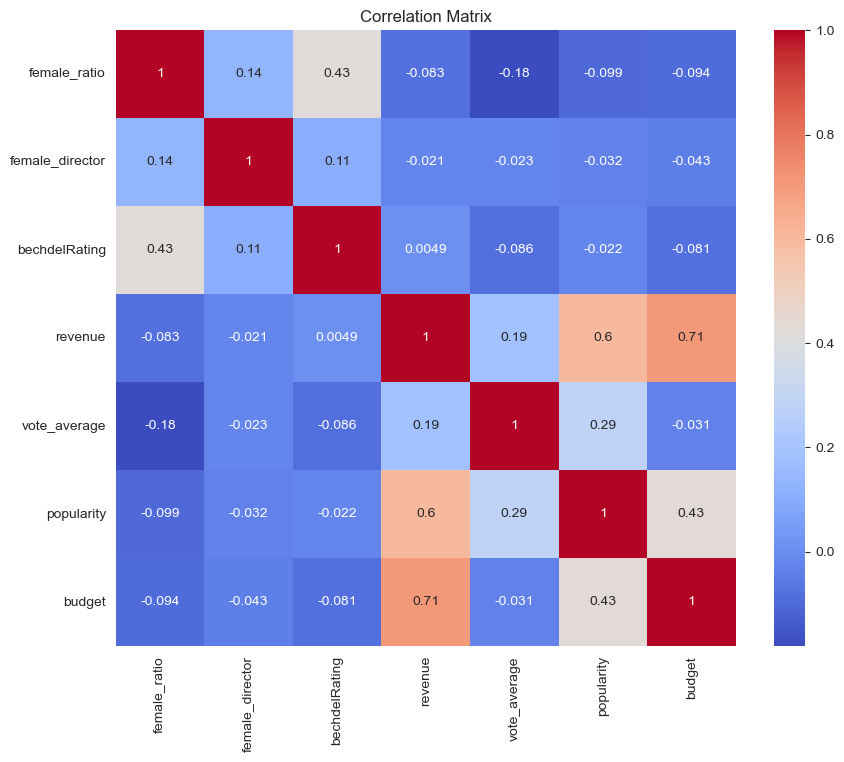

In [12]:
# Correlation matrix

corr = df[['female_ratio','female_director','bechdelRating',
           'revenue','vote_average','popularity','budget']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [16]:
# Top female representation movies

df.sort_values("female_ratio", ascending=False).head(10)

,title,year,budget,revenue,vote_average,vote_count,popularity,female_ratio,female_director,bechdelRating,imdbAverageRating,numVotes,runtimeMinutes,genre1,genre2,genre3
2712,Dolphins and Whales: Tribes of the Ocean,2008.0,6000000,7518876,8.0,3,0.041651,1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3188,Tumbleweeds,1999.0,312000,1281176,6.2,11,1.505703,1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2099,The Women,2008.0,16000000,50007546,4.6,96,8.832100,0.909091,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
709,Practical Magic,1998.0,75000000,46683377,6.3,338,15.142701,0.818182,0,3.0,6.3,93304.0,104.0,Comedy,Drama,Fantasy
2948,Woman Thou Art Loosed,2004.0,3000000,6804016,5.0,3,0.019984,0.800000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013,Center Stage,2000.0,18000000,17200925,6.8,90,6.961736,0.800000,0,3.0,6.7,22831.0,115.0,Drama,Music,Romance
607,What Women Want,2000.0,70000000,374111707,6.1,992,31.391650,0.790909,1,1.0,6.4,222914.0,127.0,Comedy,Fantasy,Romance
513,Spanglish,2004.0,80000000,55041367,5.8,369,14.209329,0.785714,0,3.0,6.4,88659.0,131.0,Comedy,Drama,Romance
2548,Black Christmas,2006.0,9000000,21510851,4.8,119,4.134327,0.750000,0,3.0,4.7,30695.0,95.0,Horror,NaN,NaN
2404,The Secret Life of Bees,2008.0,11000000,38105395,7.4,158,7.645979,0.727273,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


FEMALE REPRESENTATION (DIRECTORS)



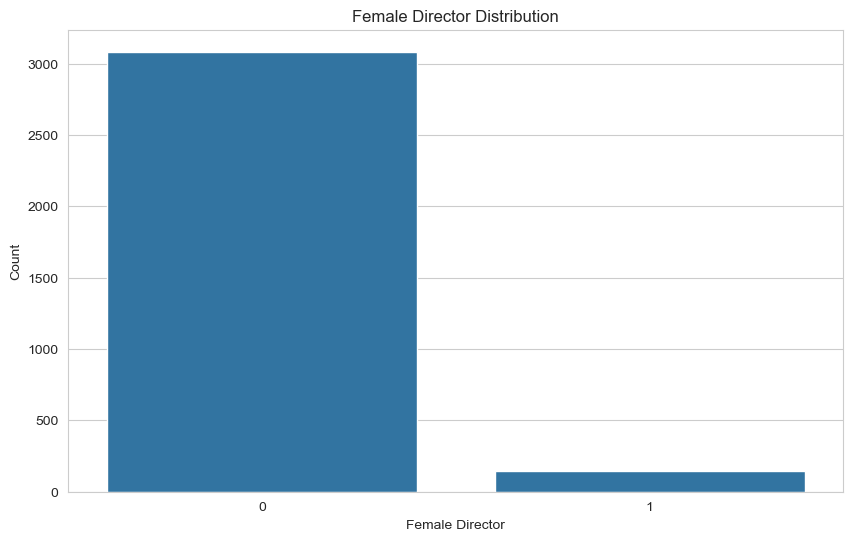

In [67]:
# Female director distribution

sns.countplot(x='female_director', data=df)

plt.title("Female Director Distribution")
plt.xlabel("Female Director")
plt.ylabel("Count")

plt.show()

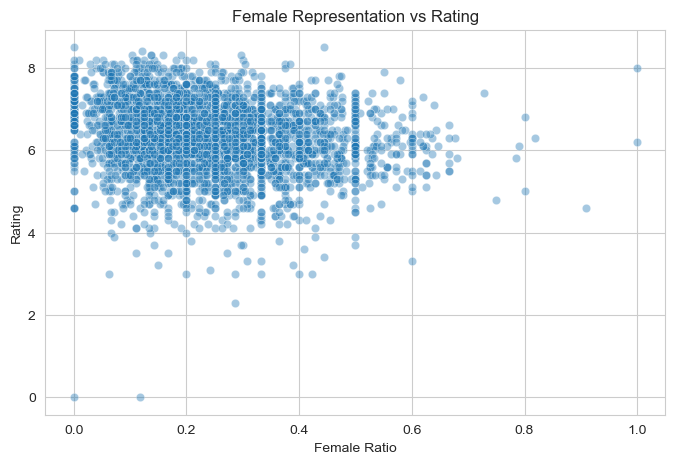

In [39]:
# Check relationship between female representation and movie rating

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='female_ratio',
    y='vote_average',
    data=df,
    alpha=0.4
)

plt.title("Female Representation vs Rating")
plt.xlabel("Female Ratio")
plt.ylabel("Rating")

plt.show()

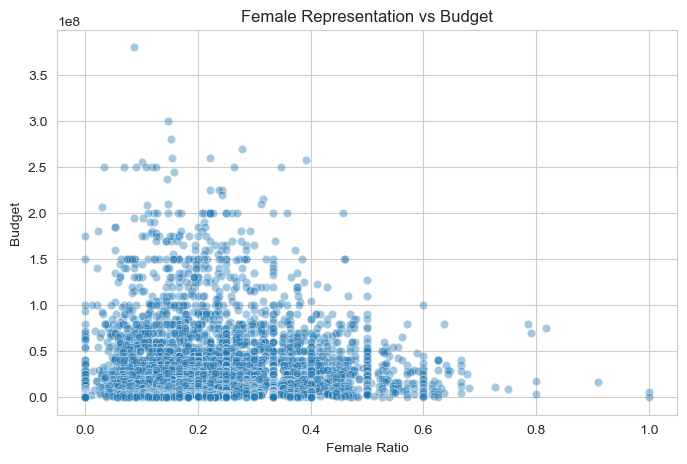

In [40]:
# Analyze whether high budget movies include more female representation

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='female_ratio',
    y='budget',
    data=df,
    alpha=0.4
)

plt.title("Female Representation vs Budget")
plt.xlabel("Female Ratio")
plt.ylabel("Budget")

plt.show()

In [20]:
# Instead of looking at revenue alone, I create a composite success score
# This helps capture multiple aspects of movie success

df['success_score'] = (
    np.log1p(df['revenue']) * 0.4 +
    df['vote_average'] * 0.3 +
    np.log1p(df['vote_count']) * 0.2 +
    np.log1p(df['popularity']) * 0.1
)

# quick look
df[['success_score']].head()

,success_score
0,13.236636
1,12.520028
2,12.277935
3,12.898291
4,11.528799


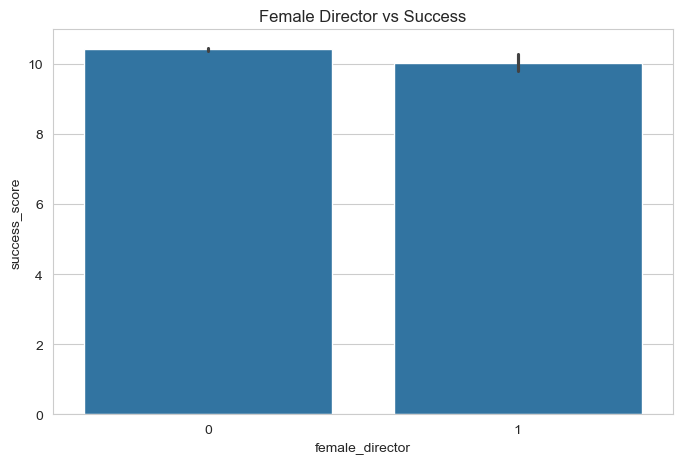

In [41]:
# Compare success scores between male and female directors

plt.figure(figsize=(8,5))

sns.barplot(
    x='female_director',
    y='success_score',
    data=df
)

plt.title("Female Director vs Success")

plt.show()

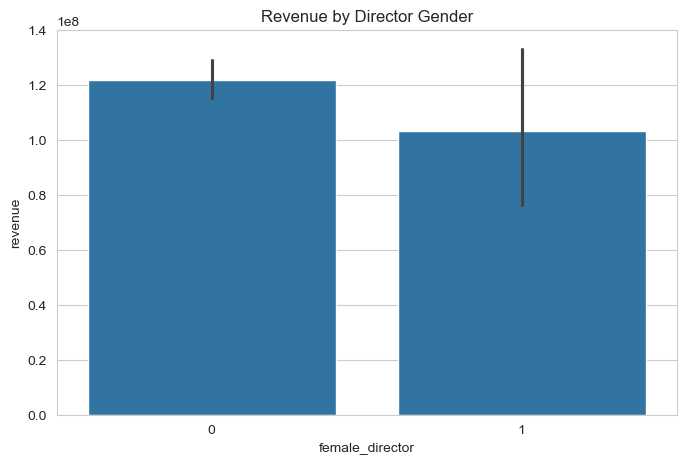

In [52]:
# Compare revenue between male and female directors

plt.figure(figsize=(8,5))

sns.barplot(
    x='female_director',
    y='revenue',
    data=df,
    errorbar=('ci',95)
)

plt.title("Revenue by Director Gender")

plt.show()

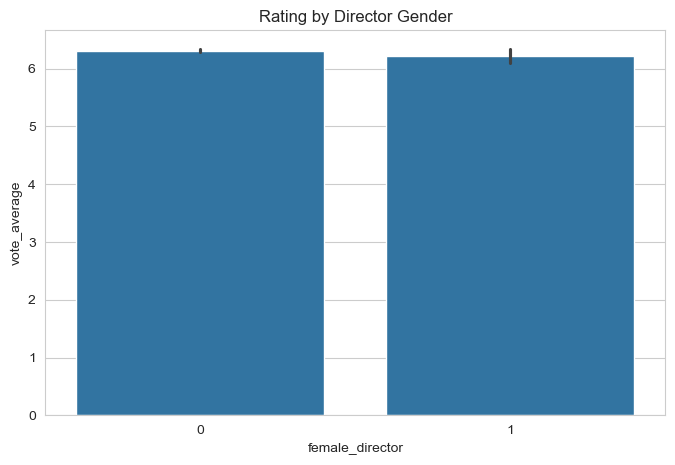

In [53]:
# Compare ratings

plt.figure(figsize=(8,5))

sns.barplot(
    x='female_director',
    y='vote_average',
    data=df,
    errorbar=('ci',95)
)

plt.title("Rating by Director Gender")

plt.show()

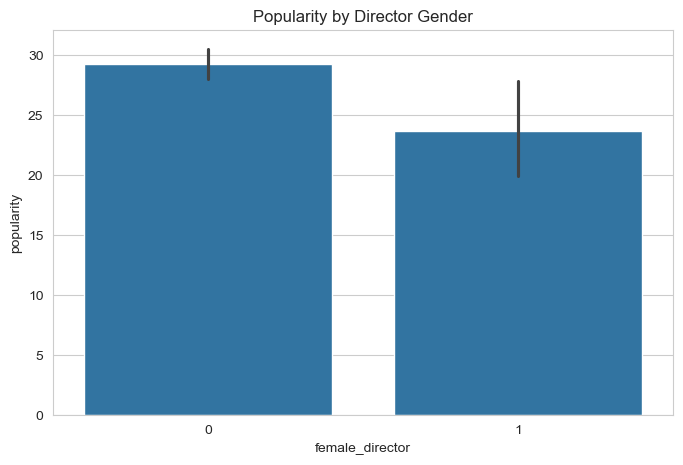

In [54]:
# Compare popularity

plt.figure(figsize=(8,5))

sns.barplot(
    x='female_director',
    y='popularity',
    data=df
)

plt.title("Popularity by Director Gender")

plt.show()

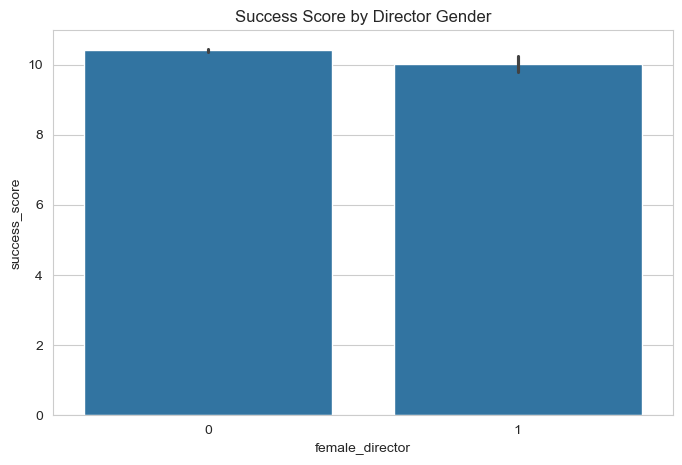

In [55]:
# Compare overall success score

plt.figure(figsize=(8,5))

sns.barplot(
    x='female_director',
    y='success_score',
    data=df,
    errorbar=('ci',95)
)

plt.title("Success Score by Director Gender")

plt.show()

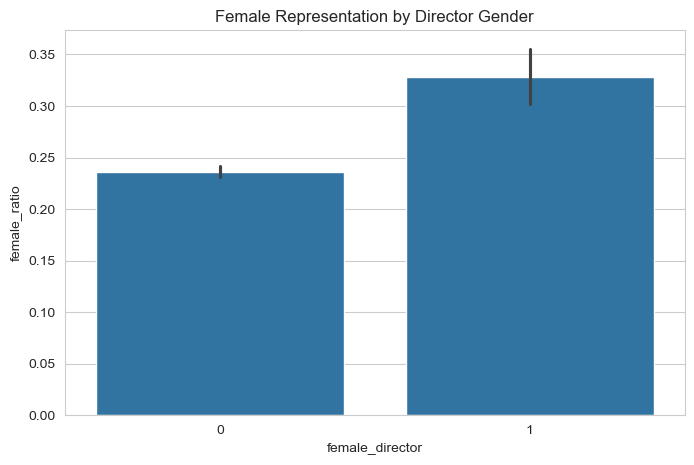

In [57]:
# Check if female directors include more female characters

plt.figure(figsize=(8,5))

sns.barplot(
    x='female_director',
    y='female_ratio',
    data=df
)

plt.title("Female Representation by Director Gender")

plt.show()

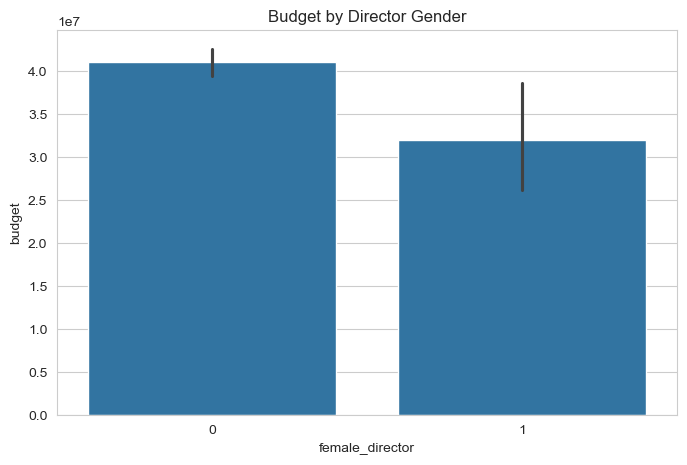

In [58]:
# Compare budgets

plt.figure(figsize=(8,5))

sns.barplot(
    x='female_director',
    y='budget',
    data=df
)

plt.title("Budget by Director Gender")

plt.show()

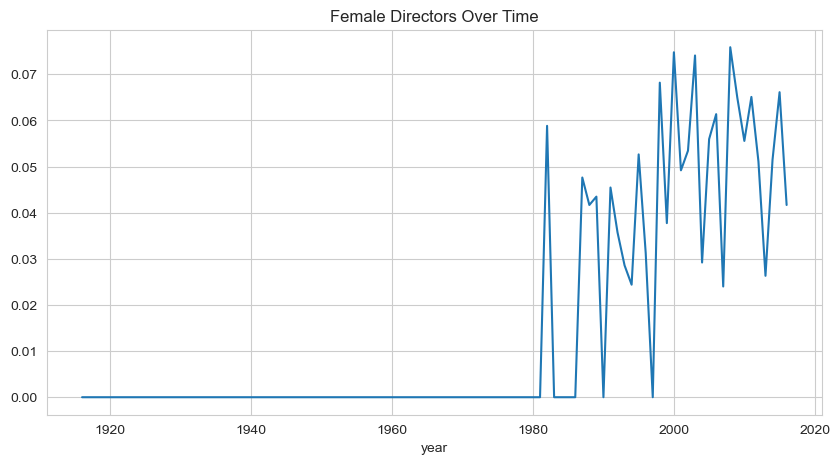

In [56]:
# Check trend over time

director_year = df.groupby('year')['female_director'].mean()

plt.figure(figsize=(10,5))

director_year.plot()

plt.title("Female Directors Over Time")

plt.show()

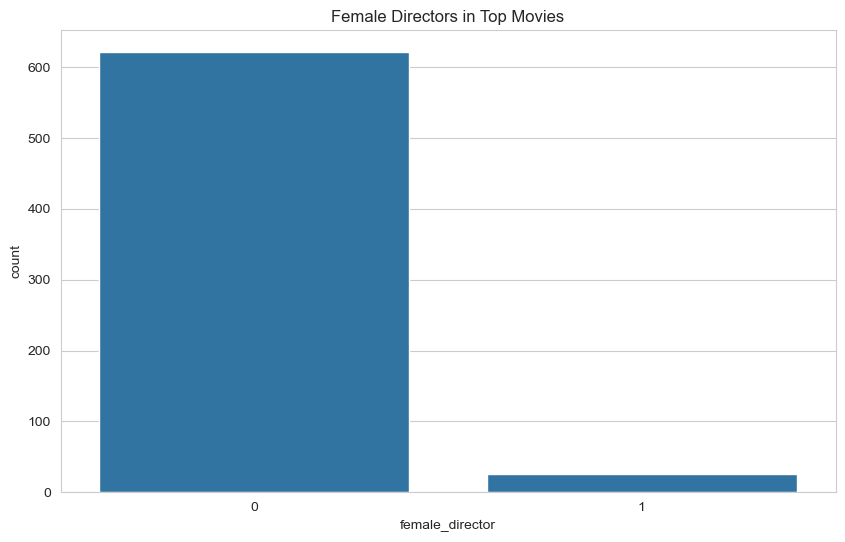

In [60]:
# Compare female directors in top movies

threshold = df['success_score'].quantile(0.8)

top_movies = df[df['success_score'] >= threshold]

sns.countplot(
    x='female_director',
    data=top_movies
)

plt.title("Female Directors in Top Movies")

plt.show()

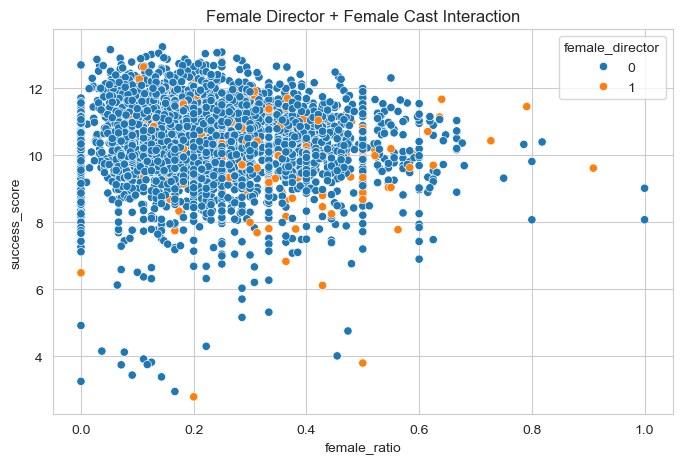

In [61]:
# Check interaction

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='female_ratio',
    y='success_score',
    hue='female_director',
    data=df
)

plt.title("Female Director + Female Cast Interaction")

plt.show()

FEMALE REPRESENTATION (CAST)

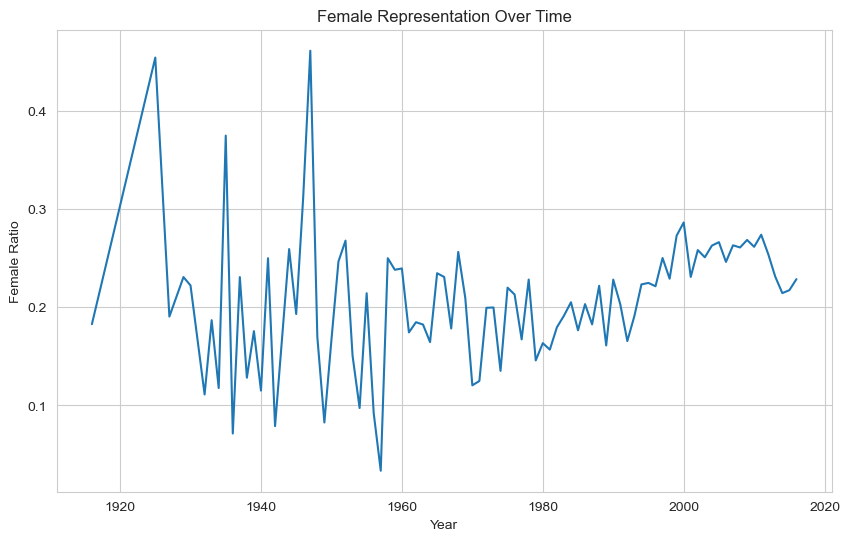

In [68]:
# Female representation over years

yearly = df.groupby('year')['female_ratio'].mean()

yearly.plot()

plt.title("Female Representation Over Time")
plt.xlabel("Year")
plt.ylabel("Female Ratio")

plt.show()

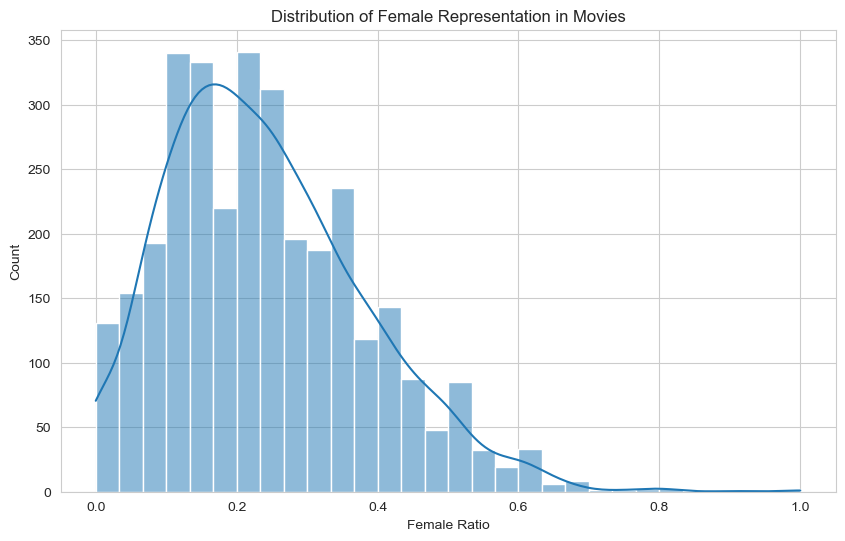

In [65]:
# Distribution of female ratio

plt.figure(figsize=(10,6))
sns.histplot(df['female_ratio'], bins=30, kde=True)

plt.title("Distribution of Female Representation in Movies")
plt.xlabel("Female Ratio")
plt.ylabel("Count")

plt.show()

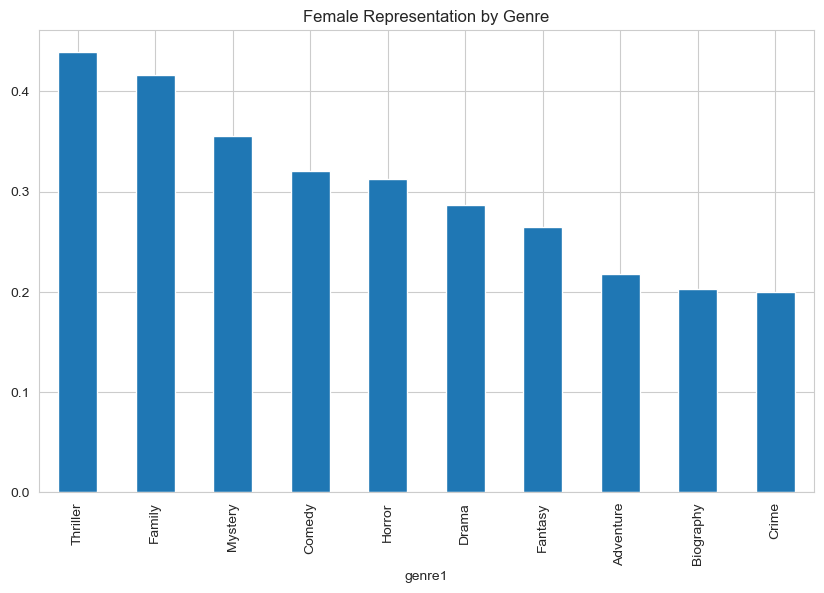

In [70]:
# Genre vs female ratio

genre = df.groupby('genre1')['female_ratio'].mean().sort_values(ascending=False)

genre.head(10).plot(kind='bar')

plt.title("Female Representation by Genre")
plt.show()

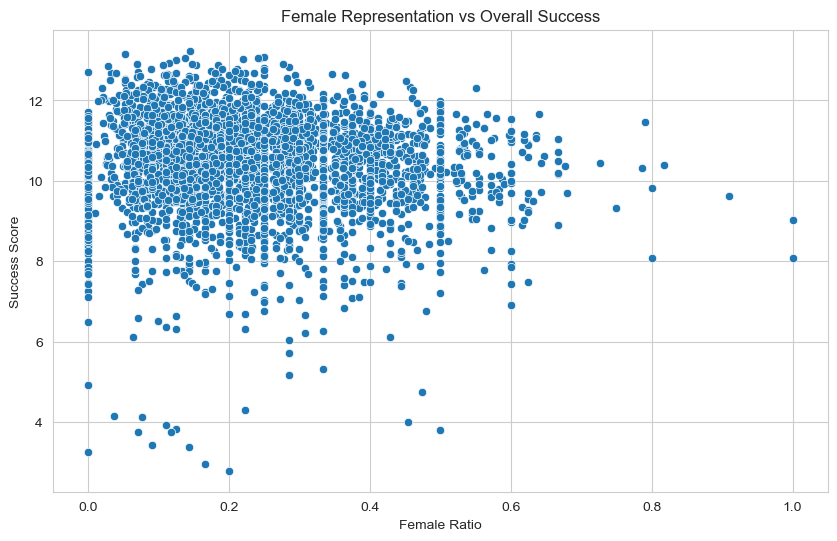

In [42]:
# Now I analyze female representation vs overall movie success

sns.scatterplot(x='female_ratio', y='success_score', data=df)

plt.title("Female Representation vs Overall Success")
plt.xlabel("Female Ratio")
plt.ylabel("Success Score")

plt.show()

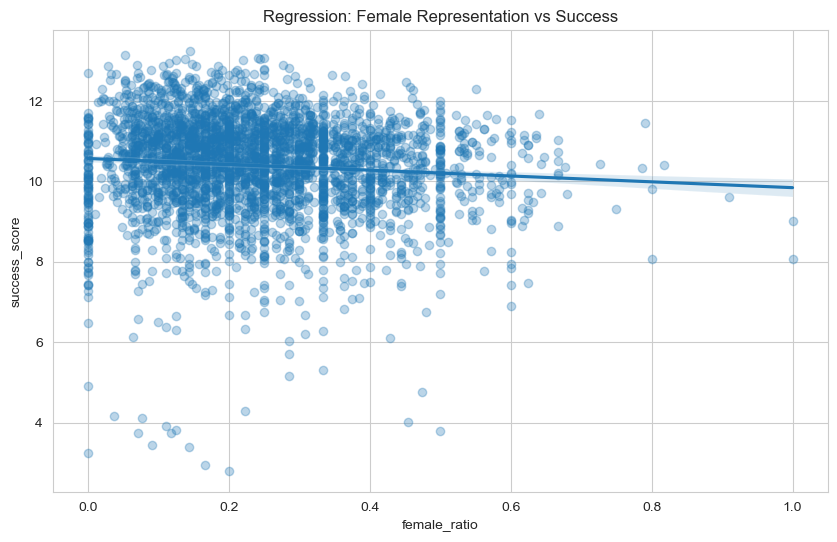

In [72]:
# Add regression line to better understand the trend

sns.regplot(
    x='female_ratio',
    y='success_score',
    data=df,
    scatter_kws={'alpha':0.3}
)

plt.title("Regression: Female Representation vs Success")

plt.show()

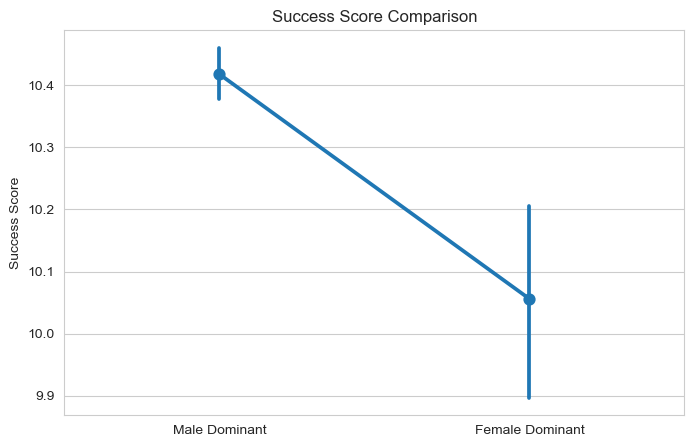

In [73]:
plt.figure(figsize=(8,5))

sns.pointplot(
    x='representation_type',
    y='success_score',
    data=df,
    errorbar=('ci',95),
    markers='o',
    linestyles='-'
)

plt.title("Success Score Comparison")
plt.xlabel("")
plt.ylabel("Success Score")

plt.show()

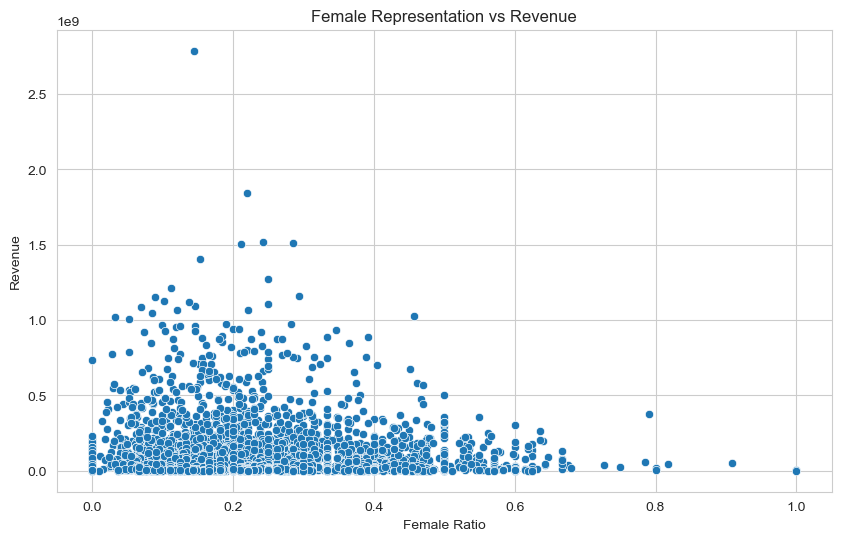

In [71]:
# Relationship between female ratio and revenue

plt.figure(figsize=(10,6))
sns.scatterplot(x='female_ratio', y='revenue', data=df)

plt.title("Female Representation vs Revenue")
plt.xlabel("Female Ratio")
plt.ylabel("Revenue")

plt.show()

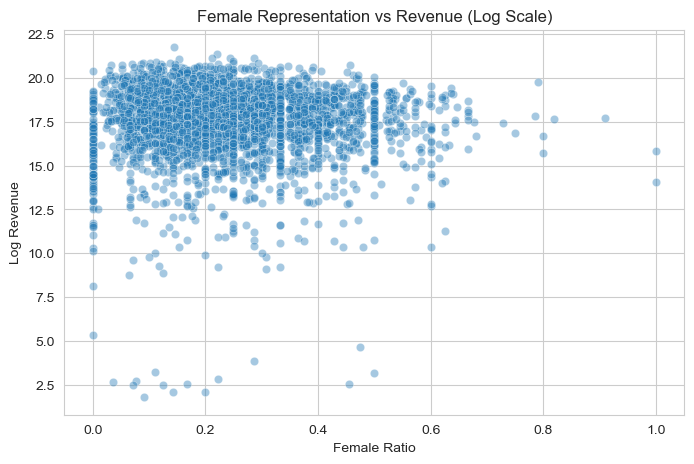

In [66]:
# Analyze relationship between female representation and revenue

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='female_ratio',
    y=np.log1p(df['revenue']),
    data=df,
    alpha=0.4
)

plt.title("Female Representation vs Revenue (Log Scale)")
plt.xlabel("Female Ratio")
plt.ylabel("Log Revenue")

plt.show()

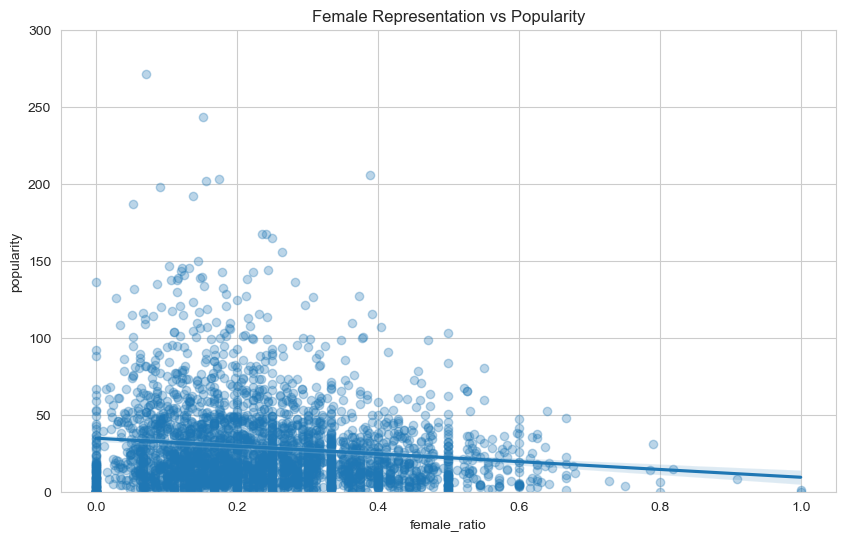

In [98]:
# I want to understand whether higher female representation
# is associated with more popular movies

sns.regplot(
    x='female_ratio',
    y='popularity',
    data=df,
    scatter_kws={'alpha':0.3}
)

plt.ylim(0, 300)  

plt.title("Female Representation vs Popularity")

plt.show()

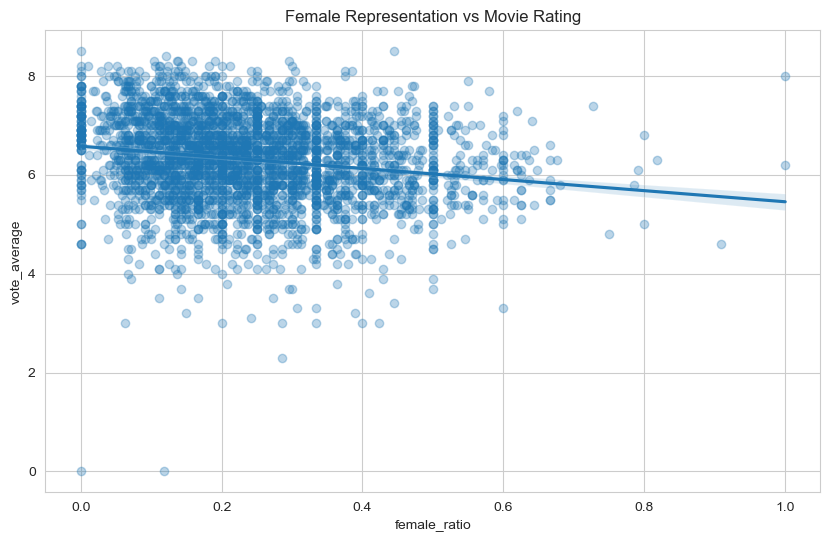

In [ ]:
# Is female representation is associated with better ratings

sns.regplot(
    x='female_ratio',
    y='vote_average',
    data=df,
    scatter_kws={'alpha':0.3}
)

plt.title("Female Representation vs Movie Rating")

plt.show()

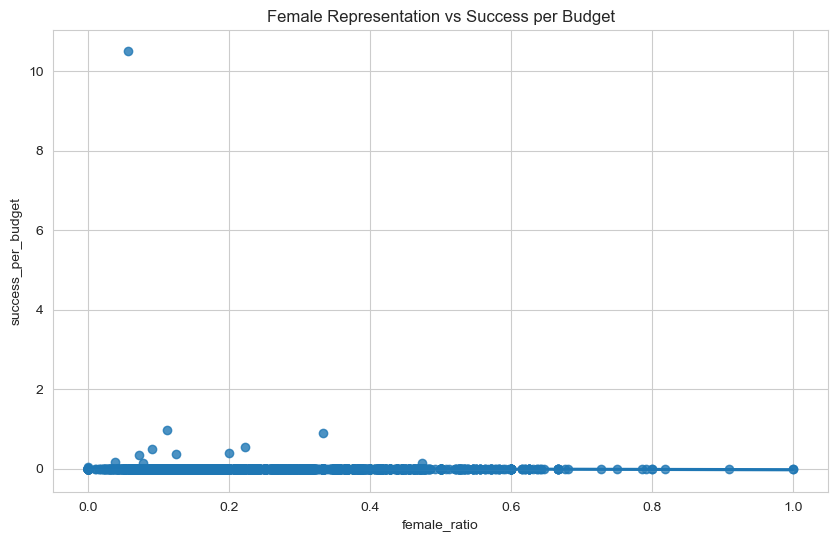

In [ ]:
# Createing normalized success score (success per budget)

df['success_per_budget'] = df['success_score'] / df['budget']

sns.regplot(
    x='female_ratio',
    y='success_per_budget',
    data=df
)

plt.title("Female Representation vs Success per Budget")

plt.show()

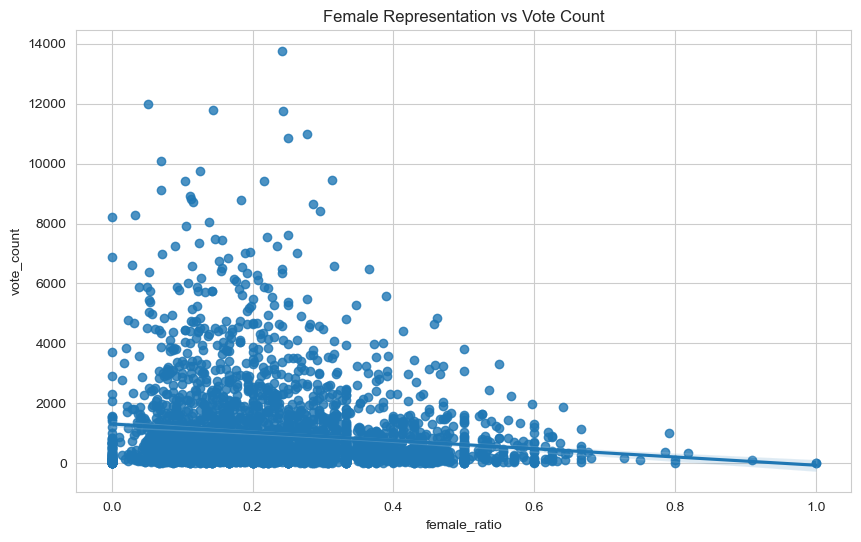

In [49]:
# Check whether female representation influences engagement

sns.regplot(
    x='female_ratio',
    y='vote_count',
    data=df
)

plt.title("Female Representation vs Vote Count")

plt.show()

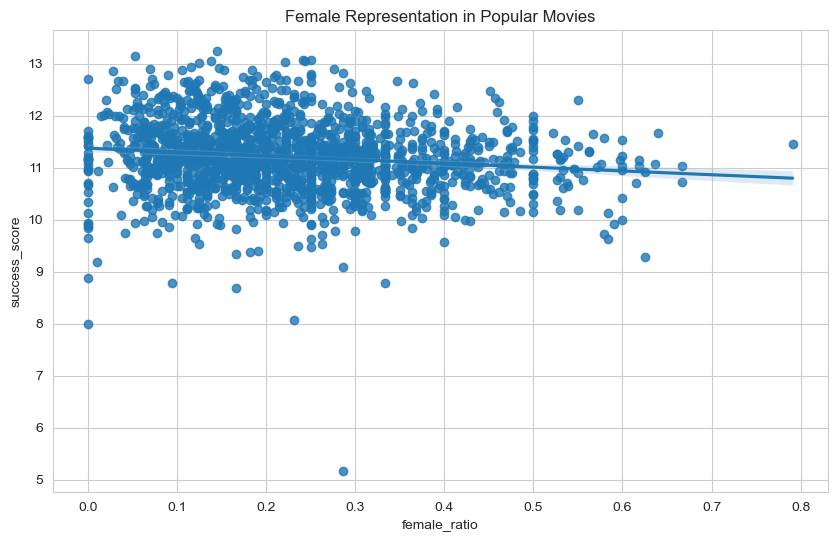

In [50]:
# Focus only on popular movies

popular = df[df['vote_count'] > df['vote_count'].median()]

sns.regplot(
    x='female_ratio',
    y='success_score',
    data=popular
)

plt.title("Female Representation in Popular Movies")

plt.show()

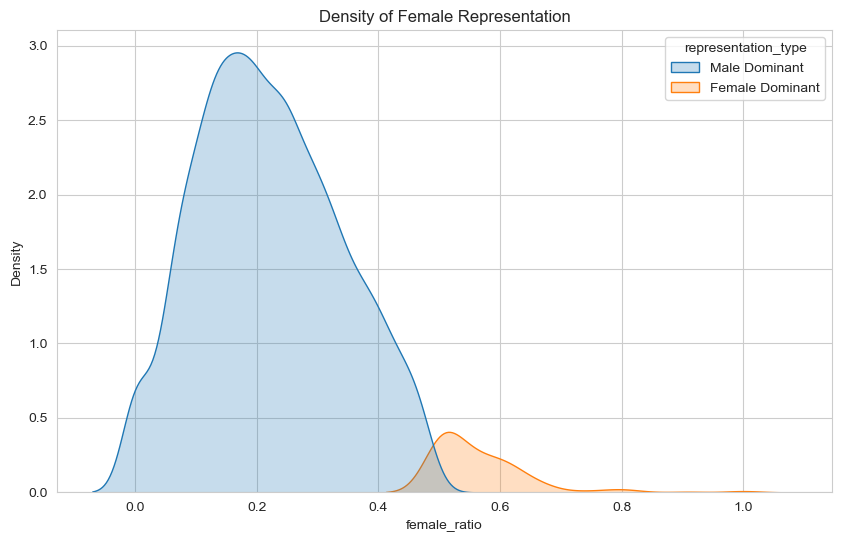

In [51]:
# Compare density of female representation

sns.kdeplot(
    data=df,
    x='female_ratio',
    hue='representation_type',
    fill=True
)

plt.title("Density of Female Representation")

plt.show()

FOR DIFFERENT GENRES


1)Female directors

In [74]:
# First, I find the top 5 most common genres

top_genres = df['genre1'].value_counts().head(5).index

print("Top 5 Genres:")
print(top_genres)

Top 5 Genres:
Index(['Action', 'Comedy', 'Drama', 'Adventure', 'Crime'], dtype='object', name='genre1')


In [75]:
# Filter dataset for top 5 genres only

top_df = df[df['genre1'].isin(top_genres)]

top_df.head()

,title,year,budget,revenue,vote_average,vote_count,popularity,female_ratio,female_director,bechdelRating,...,numVotes,runtimeMinutes,genre1,genre2,genre3,success_score,representation_type,success_per_budget,female_percentile,roi
0,Avatar,2009.0,237000000,2787965087,7.2,11800,150.437577,0.144578,0,3.0,...,1389834.0,162.0,Action,Adventure,Fantasy,13.236636,Male Dominant,5.585079e-08,Low,11.763566
2,Spectre,2015.0,245000000,880674609,6.3,4466,107.376788,0.156627,0,1.0,...,467291.0,148.0,Action,Adventure,Thriller,12.277935,Male Dominant,5.011402e-08,Low,3.594590
4,John Carter,2012.0,260000000,284139100,6.1,2124,43.926995,0.222222,0,3.0,...,286786.0,132.0,Action,Adventure,Sci-Fi,11.528799,Male Dominant,4.434153e-08,Medium,1.092843
5,Spider-Man 3,2007.0,258000000,890871626,5.9,3576,115.699814,0.391608,0,2.0,...,639892.0,139.0,Action,Adventure,Sci-Fi,12.125501,Male Dominant,4.699807e-08,Very High,3.452991
6,Tangled,2010.0,260000000,591794936,7.4,3330,48.681969,0.153846,0,3.0,...,496152.0,100.0,Adventure,Animation,Comedy,12.312238,Male Dominant,4.735476e-08,Low,2.276134


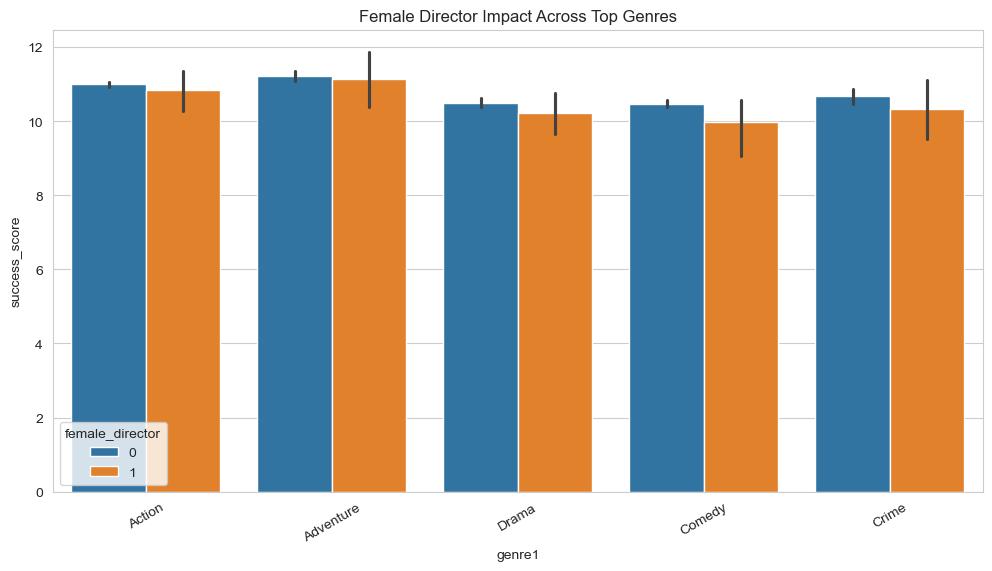

In [76]:
# Compare female director impact across top genres

plt.figure(figsize=(12,6))

sns.barplot(
    x='genre1',
    y='success_score',
    hue='female_director',
    data=top_df,
    errorbar=('ci',95)
)

plt.title("Female Director Impact Across Top Genres")
plt.xticks(rotation=30)

plt.show()

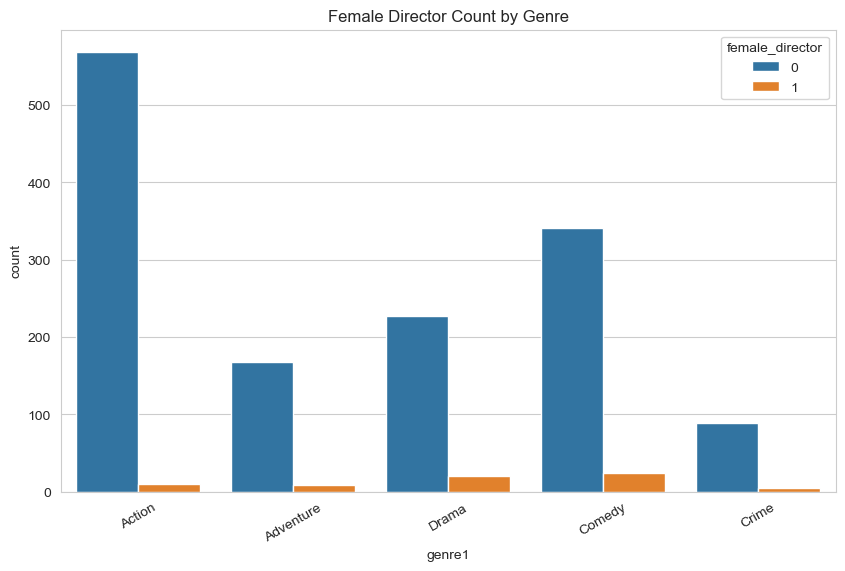

In [78]:
# Count female directors in each genre

plt.figure(figsize=(10,6))

sns.countplot(
    x='genre1',
    hue='female_director',
    data=top_df
)

plt.title("Female Director Count by Genre")

plt.xticks(rotation=30)

plt.show()

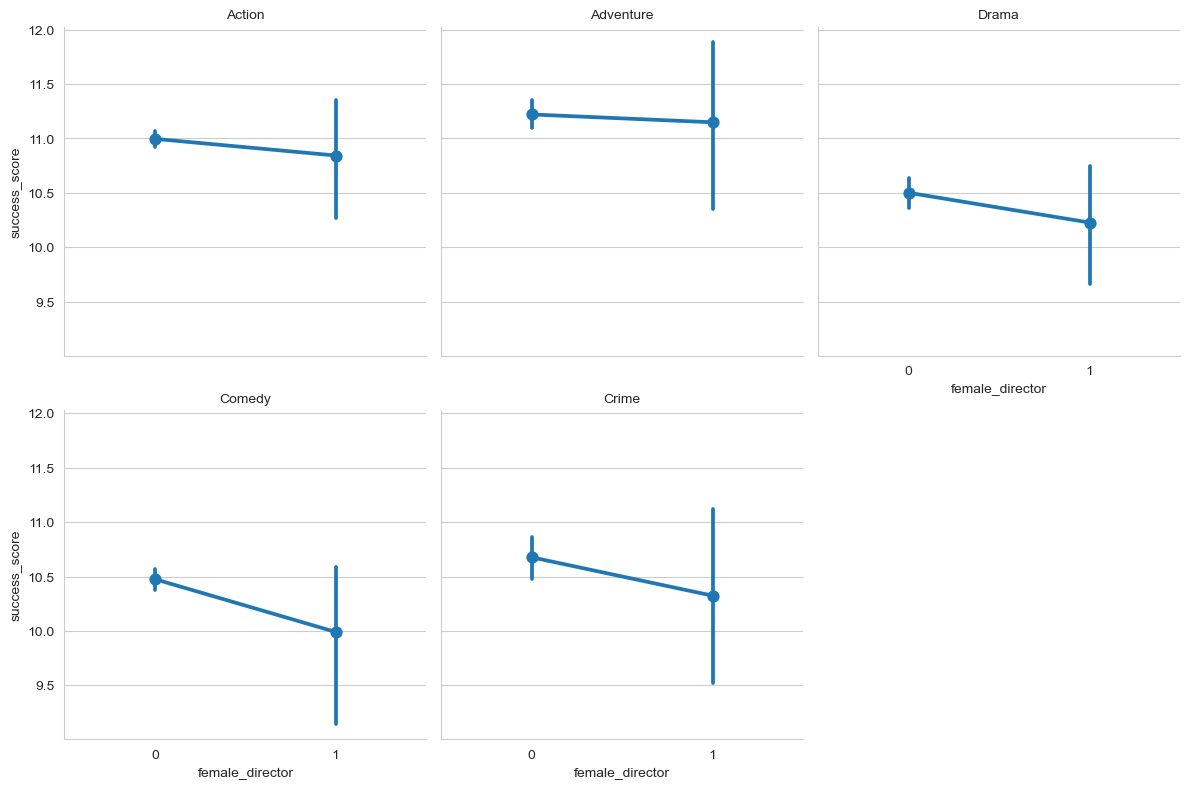

In [82]:
#succes for each genre

g = sns.FacetGrid(
    top_df,
    col="genre1",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.pointplot,
    x='female_director',
    y='success_score',
    errorbar=('ci',95)
)

g.set_titles("{col_name}")

plt.show()

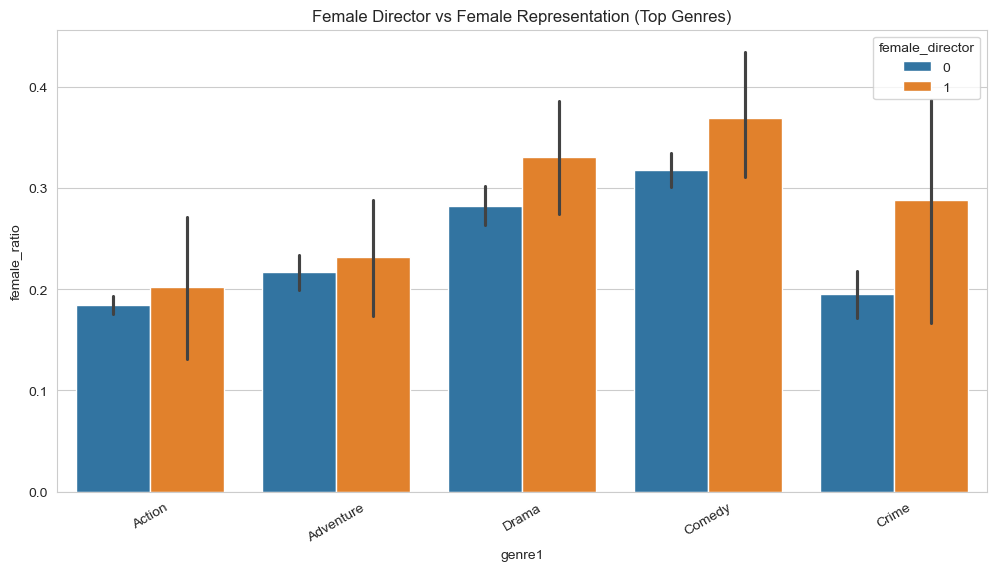

In [83]:
# Check whether female directors increase female representation in top genres

plt.figure(figsize=(12,6))

sns.barplot(
    x='genre1',
    y='female_ratio',
    hue='female_director',
    data=top_df
)

plt.title("Female Director vs Female Representation (Top Genres)")
plt.xticks(rotation=30)

plt.show()

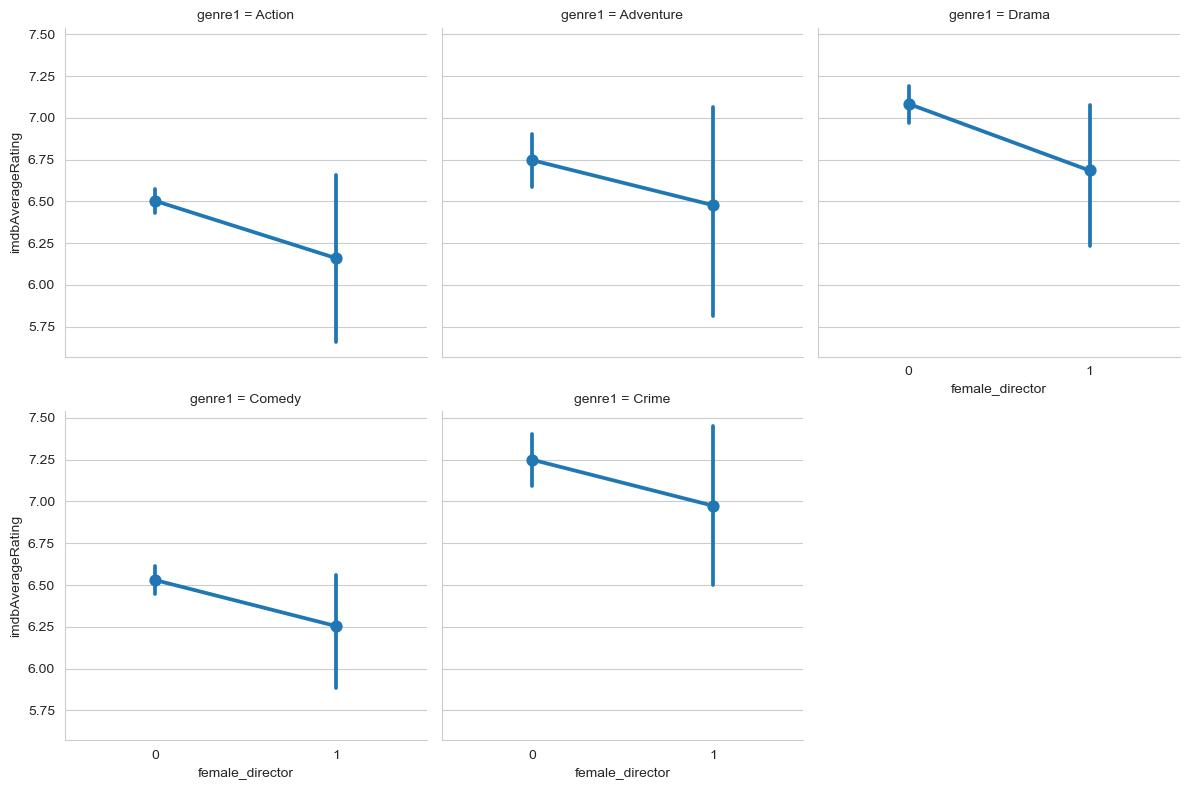

In [84]:
# Female director vs IMDb rating

g = sns.FacetGrid(
    top_df,
    col="genre1",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.pointplot,
    x='female_director',
    y='imdbAverageRating',
    errorbar=('ci',95)
)

plt.show()

2)Female represantaion by genre

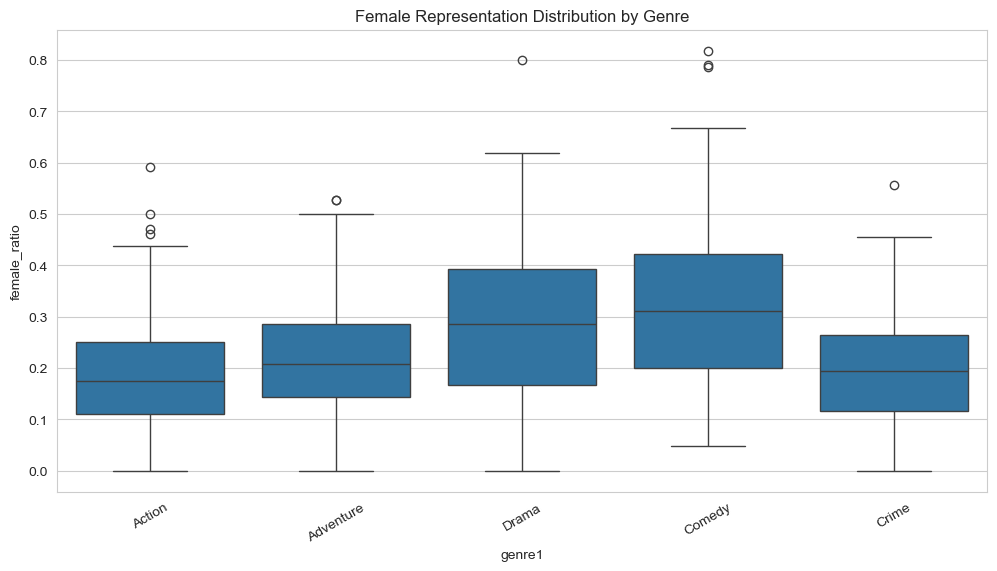

In [87]:
# Distribution of female representation across genres

plt.figure(figsize=(12,6))

sns.boxplot(
    x='genre1',
    y='female_ratio',
    data=top_df
)

plt.title("Female Representation Distribution by Genre")
plt.xticks(rotation=30)

plt.show()

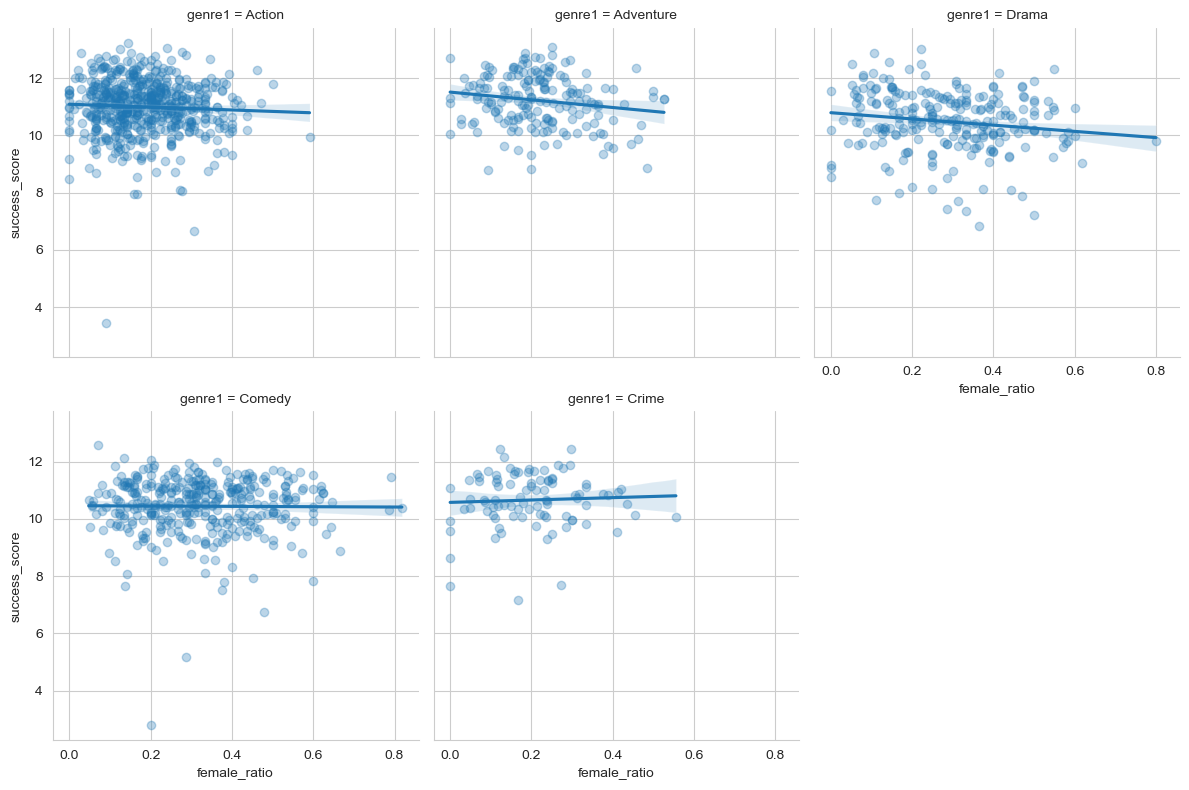

In [88]:
# Check if female representation leads to higher success in genres

g = sns.FacetGrid(
    top_df,
    col="genre1",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.regplot,
    x='female_ratio',
    y='success_score',
    scatter_kws={'alpha':0.3}
)

plt.show()

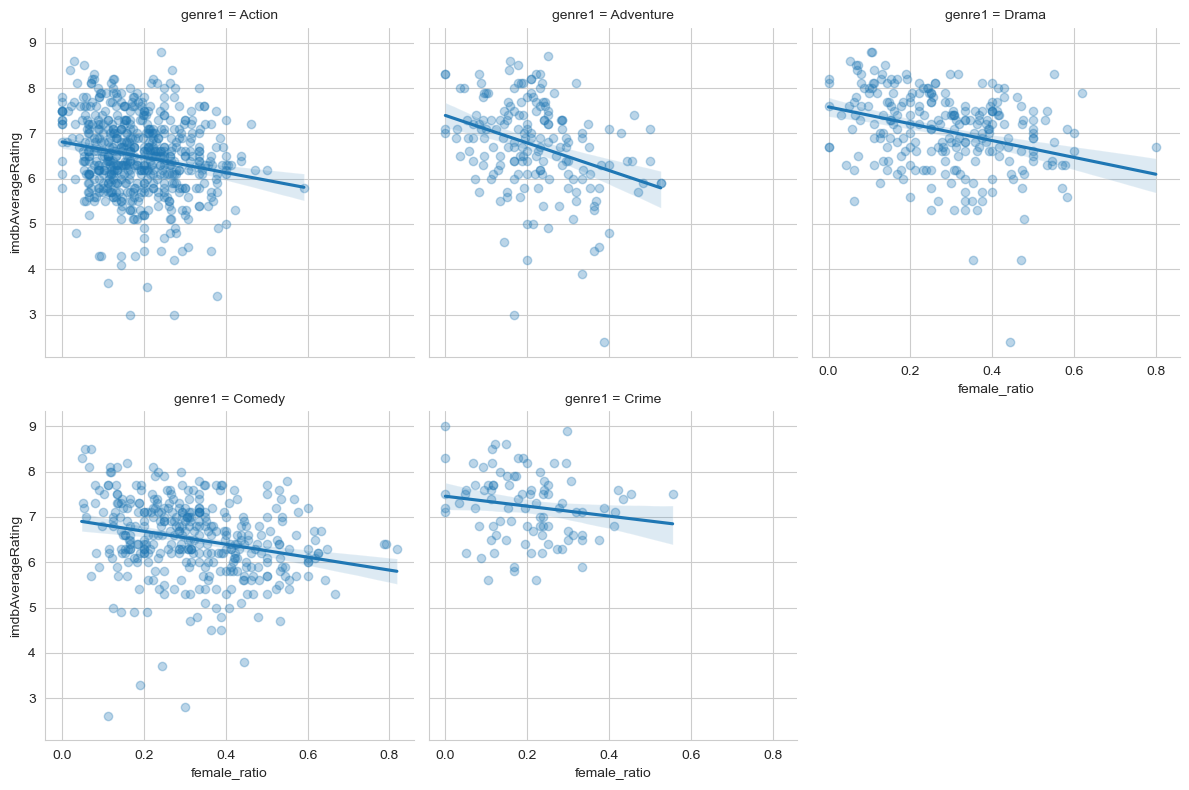

In [90]:
# Check female representation vs IMDb rating

g = sns.FacetGrid(
    top_df,
    col="genre1",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.regplot,
    x='female_ratio',
    y='imdbAverageRating',
    scatter_kws={'alpha':0.3}
)

plt.show()

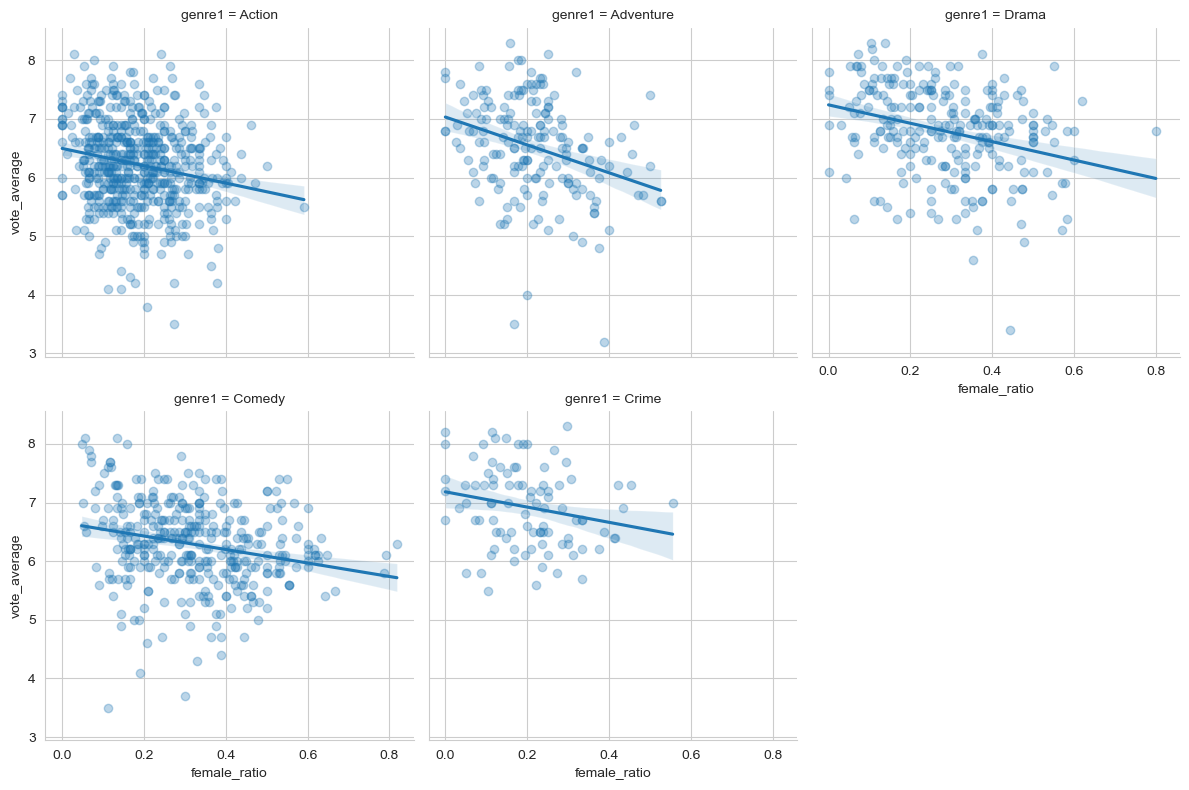

In [ ]:
# Check relationship between female representation and TMDB rating

g = sns.FacetGrid(
    top_df,
    col="genre1",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.regplot,
    x='female_ratio',
    y='vote_average',
    scatter_kws={'alpha':0.3}
)

plt.show()

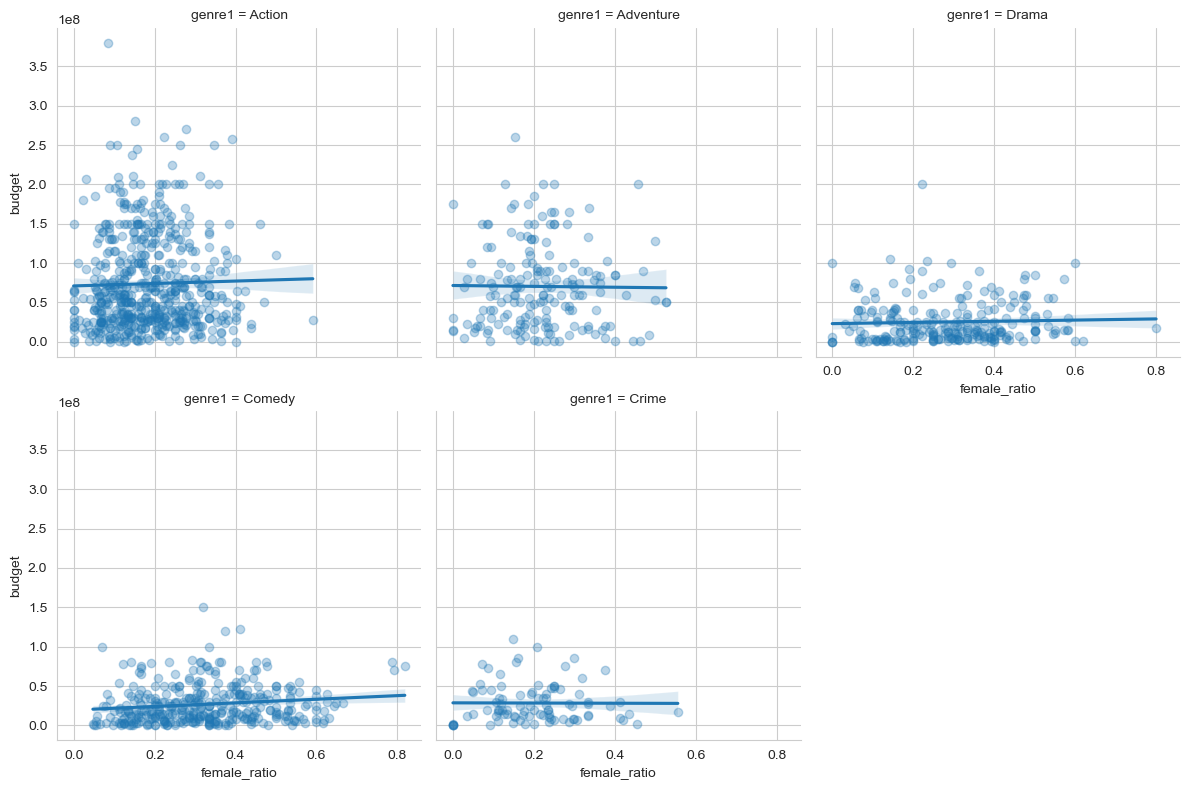

In [91]:
# Female representation vs budget

g = sns.FacetGrid(
    top_df,
    col="genre1",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.regplot,
    x='female_ratio',
    y='budget',
    scatter_kws={'alpha':0.3}
)

plt.show()

<Figure size 1400x800 with 0 Axes>

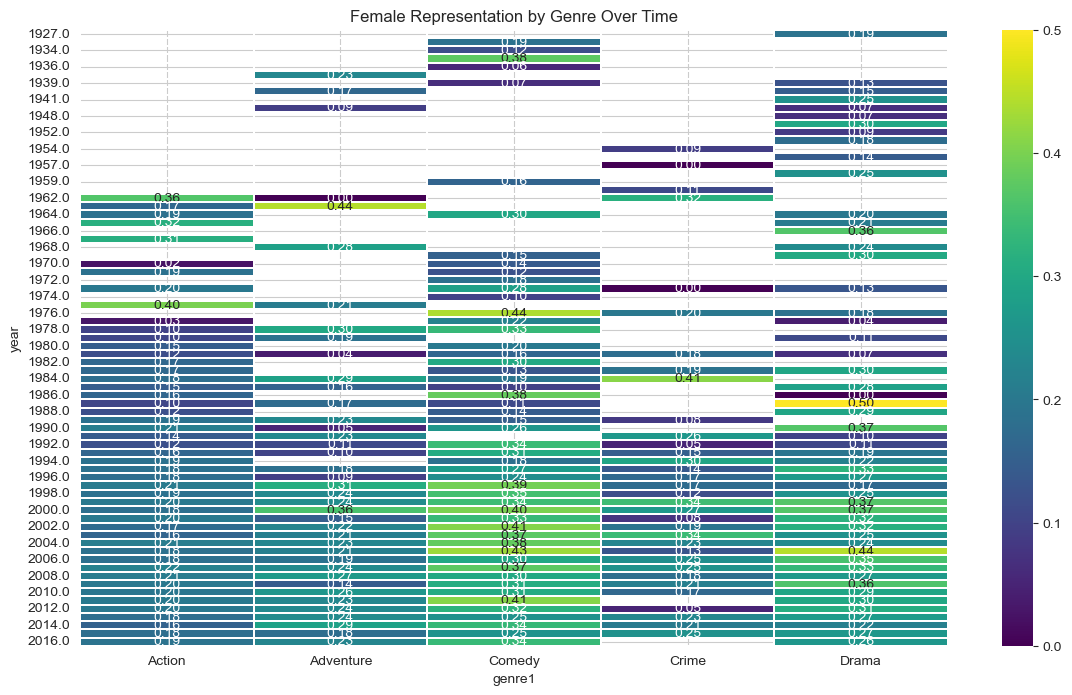

In [ ]:
#Plot heatmap of Female Representation by Genre Over Time
plt.figure(figsize=(14,8))

pivot = top_df.pivot_table(
    values='female_ratio',
    index='year',
    columns='genre1',
    aggfunc='mean'
)

# sort years
pivot = pivot.sort_index()
plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    linecolor='white'
)

plt.title("Female Representation by Genre Over Time")

plt.show()